In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Read the file you just uploaded via the sidebar
df = pd.read_csv('/content/Unemployment in India.csv')

# Strip whitespace from column names to prevent indexing errors
df.columns = df.columns.str.strip()

print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# Drop rows with missing values
df.dropna(inplace=True)

# Convert 'Date' to datetime object and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

display(df.head())

Shape of dataset: (768, 7)

Missing values:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
290,Telangana,2019-05-31,Monthly,2.23,11053353.0,61.74,Rural
276,Tamil Nadu,2019-05-31,Monthly,0.97,15844698.0,49.44,Rural
257,Rajasthan,2019-05-31,Monthly,4.03,15226005.0,38.52,Rural
243,Punjab,2019-05-31,Monthly,9.17,6088547.0,44.79,Rural


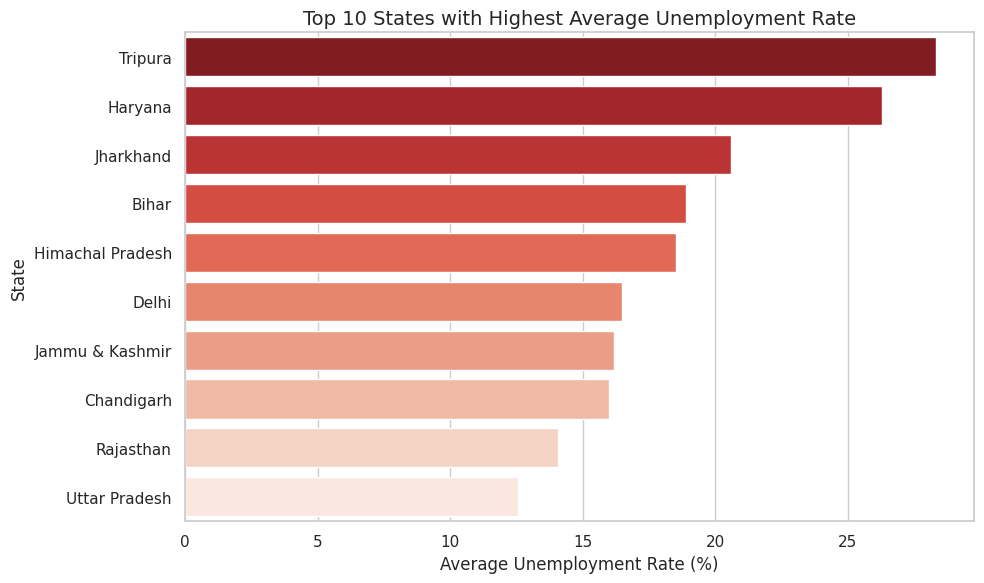

In [2]:
# Calculate mean unemployment rate per state
state_avg_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

# Plot top 10 states with highest unemployment
plt.figure(figsize=(10, 6))
sns.barplot(x=state_avg_unemp.head(10).values, y=state_avg_unemp.head(10).index, palette='Reds_r')
plt.title('Top 10 States with Highest Average Unemployment Rate', fontsize=14)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

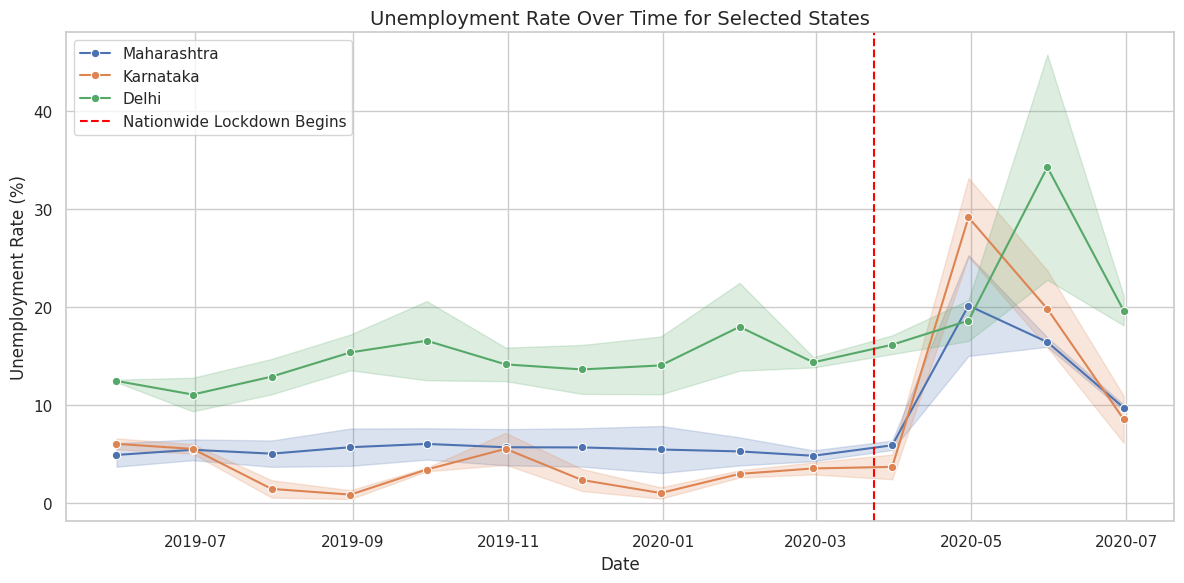

In [3]:
states_of_interest = ['Maharashtra', 'Delhi', 'Karnataka']
df_subset = df[df['Region'].isin(states_of_interest)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_subset, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title('Unemployment Rate Over Time for Selected States', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

# Highlight COVID-19 lockdown start (Late March 2020)
plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', label='Nationwide Lockdown Begins')
plt.legend()
plt.tight_layout()
plt.show()

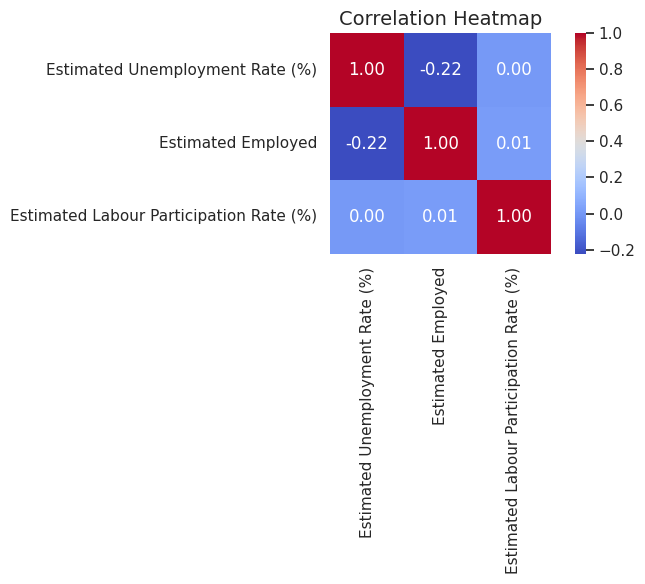

In [4]:
# Select numerical columns for correlation
cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

Average Unemployment Rate Pre-COVID (before Apr 2020): 9.61%
Average Unemployment Rate Post-COVID (Apr 2020 onwards): 20.19%


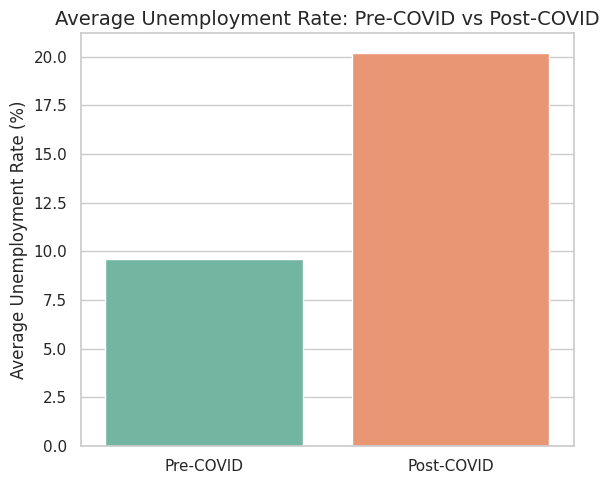

In [5]:
# Define cutoff date for COVID lockdown
cutoff_date = pd.to_datetime('2020-03-31')

# Split the dataset
pre_covid = df[df['Date'] <= cutoff_date]
post_covid = df[df['Date'] > cutoff_date]

# Calculate means
pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate Pre-COVID (before Apr 2020): {pre_mean:.2f}%")
print(f"Average Unemployment Rate Post-COVID (Apr 2020 onwards): {post_mean:.2f}%")

# Visualise the difference
plt.figure(figsize=(6, 5))
sns.barplot(x=['Pre-COVID', 'Post-COVID'], y=[pre_mean, post_mean], palette='Set2')
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID', fontsize=14)
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()